Title: Ontario weather-based crop yield forecast

Description: Utilizing machine learning to evaluate the effect of weather on crop yields



Data sources:
- Crop yield data (date range: January 1, 1887 - December 31, 2025)
  https://data.ontario.ca/dataset/ontario-field-crops-production-estimate-by-crop

- Historiscal weather data (daily data at station WOODSTOCK for years 1887-2006 and STRATHROY-MULLIFARRY for years 2007-2025
  http://climate.weather.gc.ca/climate_data/bulk_data_e.html




Weather is one of the primary factors that affect agricultural production, and climate change has further raised concerns about its effect on crop yields.
Corn, soybean and winter wheat are the top three crop grown in Ontario.



Initial step: manually download crop data

Initial step: download weather data


```
# This is formatted as code
import os
import requests
import time
import random

# Variables should be changed before performing the process
# STRATHROY-MULLIFARRY -> climate_id=6148122        2007 - 2025
# WOODSTOCK -> climate_id=6149625                   1887 - 2006
stationIDs = ['6148122']
startYear = 2007
endYear = 2025
dailyFolder = 'Daily'
hourlyFolder = 'Hourly'
monthlyFolder = 'Monthly'

# create data folders
if not os.path.exists(dailyFolder):
    os.makedirs(dailyFolder)

if not os.path.exists(hourlyFolder):
    os.makedirs(hourlyFolder)


# download daily data
for x in stationIDs:
    station = x.strip()
    for year in range(startYear, endYear+1):
        #1. Download each month of hourly weather CSV file for the station
        print('\n- Daily data - Station {0} for {1}...'.format(station, year))
        url = 'http://climate.weather.gc.ca/climate_data/bulk_data_e.html?format=csv&climate_id={0}&Year={1}&Month=1&Day=1&timeframe=2&submit=Download+Data'.format(station, year)
        csvFileName = 'Station_{0}_{1}.csv'.format('6149625', year)
        response = requests.get(url)
        with open(os.path.join(dailyFolder, csvFileName), 'wb') as f:
            f.write(response.content)
```



Step 1: Crop yield data

  Create Ontario crop yields line charts



In [ ]:
import pandas as pd
import numpy as np
import math
from bokeh.plotting import figure, show, output_file
from bokeh.models import CrosshairTool, CustomJSTickFormatter, Legend
from bokeh.layouts import gridplot
from bokeh.io import output_notebook

import warnings
warnings.filterwarnings('ignore')

# 1. read csv data
crop_yield_filename = 'Ontario_corn_soybeans_and_winter_wheat_yields_1887_to_2025.csv'
cols = ['year', 'Grain Corn', 'Soybean', 'Winter Wheat']
crop_yield_df = pd.read_csv(crop_yield_filename, usecols=cols, dtype={'year': str})

# 2. create plot
TOOLS = 'hover,save,pan,box_zoom,reset,wheel_zoom,tap'
plot = figure(tooltips='Year @x : $name yields = @y Bushels/Acre',
              title='Ontario Grain Corn, Soybeans and Winter Wheat Yields',
              x_axis_label='Year',
              y_axis_label='Bushels/Acre', tools=TOOLS, toolbar_location='above',
              x_range=crop_yield_df['year'], width=800, height = 400)


# 3. Define custom labels for the ticks (to solve long x-axis label issue)
xaxis_label_dict = {}
for i, val in enumerate(crop_yield_df['year']):
    if (int(val)%5 ==0):
      xaxis_label_dict[val] = val
    else:
      xaxis_label_dict[val] = ""
#   formate x-axis labels
plot.xaxis.formatter = CustomJSTickFormatter(
    args={'new_names': xaxis_label_dict},
    code='''
    return (tick in new_names) ? new_names[tick] : tick
    ''')
plot.xaxis.major_label_orientation = math.pi / 4    # Rotate axis' labels

# 4. plot
x = crop_yield_df['year']
y = crop_yield_df['Grain Corn']
plot.line(x, y, name='Grain Corn',  legend_label='Grain Corn',  line_color='blue')
y = crop_yield_df['Soybean']
plot.line(x, y, name='Soybean',     legend_label='Soybean',     line_color='Maroon')
y = crop_yield_df['Winter Wheat']
plot.line(x, y, name='Winter Wheat', legend_label='Winter Wheat', line_color='green')
plot.legend.location = "top_left"
plot.xgrid.grid_line_color = None
plot.axis.minor_tick_line_color = None
output_notebook()
show(plot)

#output_file('cropyield.html')


Discussion: there has been a positive trend which shows a significant increase in the yield over the years 1887 to 2025. The overall linear yield increase, there is obvious year-to-year yield fluctuations (up and down) which could be caused by climate variables including amount and distribution of annual and growing season precipitation. This will further necessitate quantifying the effect of climate change on yield variability on regional and local scales and, more importantly, yield prediction under different climates.



---

Step 2: Weather data

Most crop production in Ontario is concentrated in the Southern and Southwestern parts of Ontario.
Ontario has 1642 weather stations. Criteria to select weather stations for this project:

- has daily data from 1887 to 2025
- located within most crop production area (Southern and Southwestern parts of Ontario).
==>  WOODSTOCK and STRATHROY-MULLIFARRY are selected.
WOODSTOCK for years 1887-2006 and STRATHROY-MULLIFARRY for years 2007-2025

--

Read daily weather data and generate monthly weather data for summer season (from May to October).
- load daily weather data files (133 files wiyth 50,370 rows).
- group daily weather data by (year, month).
- drop weather data for winter season, keep data from May 01 to October 31.
- generate monthly average of daily maximum temperature, average of daily mninimum temperature, average of daily mean temperature, minimum of daily maximum temperature (24 series temperature variables) and monthly total rain/precipitation (12 series total rain/precipitation).
- plot 6 temperature figures (for 6 months May-October) with 24 lines for 24 series temperature variables.

In [ ]:

# 0. init variables * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * *
stationID = '6149625'
startYear = 1887
endYear = 2025

# 1. read daily csv files to data frame * * * * * * * * * * * * * * * * * * * * * * * * * * *
cols = ['Date/Time', 'Year', 'Month', 'Day', 'Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)', 'Total Rain (mm)', 'Total Precip (mm)']

df = pd.DataFrame()
for year in range(startYear, endYear+1):
    daily_df = pd.read_csv(f'Station_{stationID}_{year}.csv', usecols=cols, dtype = {'Date/Time': str, 'Year': str, 'Month': str, 'Day': str})
    df = pd.concat([df, daily_df], ignore_index=True)

# 2. data cleaning* * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * *
#   Filter rows where 'month' is in period from November 1st to April 30th
months = ['05', '06', '07', '08', '09', '10']
summer_weather_df = df[df['Month'].isin(months)]
#   Drop rows if 'Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)' are empty
#summer_weather_df.dropna(axis = 0, subset = ['Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)'], how = 'all', inplace = True)
#summer_weather_df.fillna(0)

# 3. Group weather data by ['Year','Month'] and generate statistics data  * * * * * * * * * *
summer_weather_group = summer_weather_df.groupby(['Year','Month'])
summer_weather_stats = summer_weather_group.agg(mean_maxtemp=('Max Temp (°C)', 'mean'),
                    mean_mintemp=('Min Temp (°C)', 'mean'),
                    mean_meantemp=('Mean Temp (°C)', 'mean'),
                    min_mintemp=('Min Temp (°C)', 'min'),
                    total_rain=('Total Rain (mm)', 'sum'),
                    total_precip=('Total Precip (mm)', 'sum'))

# 4. plot temperature by month
def plot_temp(weather_stats, crop_yield_df, years, month, month_label):
    #  filter data by month and combine with crop data
    idx = pd.IndexSlice
    month_stats = weather_stats.loc[idx[:, month], :]
    month_stats['year'] = years
    combined_month_stats = month_stats.join(crop_yield_df.set_index("year"), on="year")
    #print(combined_month_stats)

    # 4.2 Create new figure for weather of May
    output_notebook()
    plot = figure(tooltips='Year @x : $name  = @y)',
                  title='Average of Max Temp(°C), Mean Temp(°C), Min Temp(°C) of '+month_label,
                  x_axis_label='Year',
                  y_axis_label='Temperature (°C)',
                  x_range=combined_month_stats['year'], width=800, height = 500)

    # 4.3 Define custom labels for the ticks (to solve long x-axis label issue)
    xaxis_label_dict = {}
    for i, val in enumerate(combined_month_stats['year']):
        if (int(val)%5 ==0):
          xaxis_label_dict[val] = val
        else:
          xaxis_label_dict[val] = ""
    #   formate x-axis labels
    plot.xaxis.formatter = CustomJSTickFormatter(
        args={'new_names': xaxis_label_dict},
        code='''
        return (tick in new_names) ? new_names[tick] : tick
        ''')
    plot.xaxis.major_label_orientation = math.pi / 4    # Rotate axis' labels

    # 4.4 add multiple lines
    x = combined_month_stats['year']
    y = combined_month_stats['mean_maxtemp']
    plot.line(x, y, name='Average of max temerature', legend_label='Average of max temperature', line_color='DarkOliveGreen', line_width=1, line_dash='dotdash')
    y = combined_month_stats['mean_meantemp']
    plot.line(x, y, name='Average of mean temerature', legend_label='Average of mean temperature', line_color='Olive', line_width=1, line_dash='solid')
    y = combined_month_stats['mean_mintemp']
    plot.line(x, y, name='Average of min temerature', legend_label='Average of min temperature', line_color='OliveDrab', line_width=1, line_dash='dotted')
    #y = combined_month_stats['min_mintemp']
    #plot.line(x, y, name='Minimum of mininmum daily temerature', legend_label='Minimum of min temperature', line_color='LightGray', line_width=1, line_dash='dotted')

    '''
    y = combined_month_stats['Grain Corn']
    plot.line(x, y, name='Grain Corn',  legend_label='Grain Corn',  line_color='blue')
    y = combined_month_stats['Soybean']
    plot.line(x, y, name='Soybean',     legend_label='Soybean',     line_color='red')
    y = combined_month_stats['Winter Wheat']
    plot.line(x, y, name='Winter Wheat', legend_label='Winter Wheat', line_color='green')
    plot.legend.location = 'top_left'
    '''
    plot.legend.location = (600,1)
    plot.xgrid.grid_line_color = None
    plot.axis.minor_tick_line_color = None
    plot.legend.background_fill_alpha = 0.2
    plot.y_range.start = 0
    plot.y_range.end = 30

    return plot

years = list(summer_weather_df.groupby(['Year']).groups.keys())
plot_May = plot_temp(weather_stats=summer_weather_stats, crop_yield_df=crop_yield_df, years=years, month='05', month_label='May')
plot_May.legend.location = (500,1)
plot_May.circle(x=110.5, y=9.074, size = 5, color = 'red')
show(plot_May)
plot_May.legend.location = (500,1)

plot_Jun = plot_temp(weather_stats=summer_weather_stats, crop_yield_df=crop_yield_df, years=years, month='06', month_label='Jun')
plot_Jul = plot_temp(weather_stats=summer_weather_stats, crop_yield_df=crop_yield_df, years=years, month='07', month_label='Jul')
plot_Aug = plot_temp(weather_stats=summer_weather_stats, crop_yield_df=crop_yield_df, years=years, month='08', month_label='Aug')
plot_Sep = plot_temp(weather_stats=summer_weather_stats, crop_yield_df=crop_yield_df, years=years, month='09', month_label='Sep')
plot_Oct = plot_temp(weather_stats=summer_weather_stats, crop_yield_df=crop_yield_df, years=years, month='10', month_label='Oct')

grid_plots = [plot_May, plot_Jun, plot_Jul, plot_Aug, plot_Sep,plot_Oct]
grid = gridplot(grid_plots, ncols=2, width=480, height=230)
show(grid)


Analysis precipitation/rain and create precipitation vstack chart

In [ ]:

years  = list(summer_weather_df.groupby(['Year']).groups.keys())
months = ['05', '06', '07', '08', '09', '10']
month_labels = ['May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']
colors = ['SteelBlue', 'Chocolate', 'GreenYellow', 'Crimson', 'Plum', 'SaddleBrown']

summer_precip_stats = pd.crosstab(summer_weather_df['Year'], summer_weather_df['Month'], values=summer_weather_df['Total Precip (mm)'], aggfunc='sum')
summer_precip_stats['year'] = years
summer_precip_stats.reset_index(drop=True, inplace=True)

# plot data in Stack manner of bar type
plot_precip = figure(x_range=years, title='Total precipitation by year',
                     tools="hover", tooltips="@year-$name: @$name (mm)",
                     width=1000, height = 600)
plot_precip.vbar_stack(months, x='year', source=summer_precip_stats, color=colors, width=0.4, legend_label=month_labels)

# Define custom labels for the ticks (to solve long x-axis label issue)
xaxis_label_dict = {}
for i, val in enumerate(summer_precip_stats['year']):
    if (int(val)%5 ==0):
      xaxis_label_dict[val] = val
    else:
      xaxis_label_dict[val] = ""
#   formate x-axis labels
plot_precip.xaxis.formatter = CustomJSTickFormatter(
    args={'new_names': xaxis_label_dict},
    code='''
    return (tick in new_names) ? new_names[tick] : tick
    ''')
plot_precip.xaxis.major_label_orientation = math.pi / 4    # Rotate axis' labels

#plot_precip.x_range.range_padding = 0.1
plot_precip.xgrid.grid_line_color = None
plot_precip.axis.minor_tick_line_color = None
plot_precip.outline_line_color = None
plot_precip.xaxis.axis_label = 'Year'
plot_precip.yaxis.axis_label = 'Total precipitation (mm)'
plot_precip.legend.orientation = 'horizontal'
plot_precip.legend.location = "top_left"
plot_precip.y_range.start = 0
show(plot_precip)



Precipitation head map

In [ ]:
from bokeh.models import HoverTool, LabelSet, ColumnDataSource, LinearColorMapper, BasicTicker, PrintfTickFormatter, ColorBar
from bokeh.palettes import Spectral11, colorblind, Inferno, BuGn, brewer


precip_df = summer_weather_df[['Year', 'Month', 'Total Precip (mm)']].copy()
month_precip_df = precip_df.groupby(['Year', 'Month']).sum().reset_index()
month_precip_df.rename(columns={'Total Precip (mm)': 'precip'}, inplace=True)

month_precip_df['Year'] = month_precip_df['Year'].astype(int)
month_precip_df['Month'] = month_precip_df['Month'].astype(int)


precip_heatmap = figure(title="Month-Year Total precipitation (mm)", tools=TOOLS, toolbar_location='above', width = 1000, height = 200)
source = ColumnDataSource(month_precip_df)
colors = brewer['BuGn'][6]
colors = colors[::-1]
mapper = LinearColorMapper(palette=colors, low=month_precip_df.precip.min(), high=month_precip_df.precip.max())

precip_heatmap.rect(x='Year', y='Month', width=2, height=1, source=source,
    fill_color={
        'field': 'precip',
        'transform': mapper
    },
    line_color=None)

color_bar = ColorBar(
    color_mapper=mapper,
    major_label_text_font_size="10pt",
    ticker=BasicTicker(desired_num_ticks=len(colors)),
    formatter=PrintfTickFormatter(),
    label_standoff=6,
    border_line_color=None,
    location=(0, 0))

precip_heatmap.add_layout(color_bar, 'right')
precip_heatmap.xaxis.axis_label = 'Year'
precip_heatmap.yaxis.axis_label = 'Month'
precip_heatmap.select_one(HoverTool).tooltips = [('Year', '@Year'),('Month', '@Month'), ('precip', '@precip')]

show(precip_heatmap)


Crop yield data:
- Grain corn: from 1893 to 2025
- Soybean: from 1942 to 2025
- Winter wheat: from 1887 to 2025

So crop yield data from 1942 to 2025 is used for

1. Generate trend & slope of all 33 variables
  ==> crop yields and weather are in positive trend (positive slope) over the years 1942-2025

2. Check hypotheses
    
    H1: low temperatures in Ontario during May can significantly impact crop yields by delaying planting, slowing germination, causing injury to early-emerged crops. These conditions often lead to poor or uneven emergence, reducing plant stands and overall yield potential?
    
    H2: low precipitation/rain in July, august can effect soybean and corn yeilds?




In [ ]:
import datetime as dt

# 0. initial variables
stationID = '6149625'
startYear = 1942
endYear = 2025
crop_yield_filename = 'Ontario_corn_soybeans_and_winter_wheat_yields_1942_to_2025.csv'

# 1. read crop yields data from csv file
cols = ['year', 'Grain Corn', 'Soybean', 'Winter Wheat']
crop_yield_df = pd.read_csv(crop_yield_filename, usecols=['year', 'Grain Corn', 'Soybean', 'Winter Wheat'], dtype={'year': str})

# 2. read weather data from 1942 to 2025 and weather data cleaning
#   Read data from csv files
cols = ['Date/Time', 'Year', 'Month', 'Day', 'Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)', 'Total Rain (mm)', 'Total Precip (mm)']
df = pd.DataFrame()
for year in range(startYear, endYear+1):
    daily_df = pd.read_csv(f'Station_{stationID}_{year}.csv', usecols=cols, dtype = {'Date/Time': str, 'Year': str, 'Month': str, 'Day': str})
    df = pd.concat([df, daily_df], ignore_index=True)

#   Filter rows where 'month' is in period from November 1st to April 30th
months = ['05', '06', '07', '08', '09', '10']
summer_weather_df = df[df['Month'].isin(months)]

# 3. Group weather data by ['Year','Month'] and generate statistics data  * * * * * * * * * *
summer_weather_group = summer_weather_df.groupby(['Year','Month'])
summer_weather_stats = summer_weather_group.agg(
                    avg_maxtemp=('Max Temp (°C)', 'mean'),
                    avg_mintemp=('Min Temp (°C)', 'mean'),
                    avg_meantemp=('Mean Temp (°C)', 'mean'),
                    min_mintemp=('Min Temp (°C)', 'min'),
                    sum_rain=('Total Rain (mm)', 'sum'),
                    sum_precip=('Total Precip (mm)', 'sum')).reset_index()

# 4. crop and weather trend
#   create crop trend and slope
variables = ['Grain Corn', 'Soybean', 'Winter Wheat']
slope_df = pd.DataFrame(columns=['variable', 'month', 'trend', 'slope', 'intercept'])
for variable in variables:
    x = crop_yield_df['year'].astype(int)
    y = crop_yield_df[variable]
    slope, intercept = np.polyfit(x, y, 1)
    trend = 'positive'
    if slope <0:
        trend = 'negative'
    slope_df.loc[len(slope_df)] = [variable, '', trend, slope, intercept]

#   create weather slope and trend
months = ['05', '06', '07', '08', '09', '10']
mnames = ['May', 'June', 'July', 'August', 'September', 'October']
variables = ['avg_maxtemp', 'avg_meantemp', 'avg_mintemp', 'sum_rain', 'sum_precip']
vnames = ['Tmax', 'Tmean', 'Tmin', 'Rain', 'Precip']
for variable in variables:
    vname = vnames[variables.index(variable)]
    for month in months:
        mname = mnames[months.index(month)]
        month_df = summer_weather_stats.loc[summer_weather_stats['Month'] == month]
        x = month_df['Year'].astype(int)
        y = month_df[variable]
        slope, intercept = np.polyfit(x, y, 1)
        trend = 'positive'
        if slope <0:
            trend = 'negative'
        slope_df.loc[len(slope_df)] = [vname, mname, trend, slope, intercept]

print(slope_df)

# 5. plot trend
"""
import matplotlib.pyplot as plt
f, ax = plt.subplots(1)
fit = np.polyfit(x, y, 1)
fit_fn = np.poly1d(fit)
plt.plot(x, fit_fn(x), 'k-')
plt1 = plt.plot(x, y, 'go', ms=2)

f, ax = plt.subplots(1)
ax.plot(x, y)
ax.set_ylim(ymin=0)
fit = np.polyfit(x, y, 1)
fit_fn = np.poly1d(fit)
plt.plot(x, fit_fn(x), 'k-')
plt2 = plt.plot(x, y, 'go', ms=2)"""

# 6. plot monthly weather - crops
#   create figure
output_notebook()
def check_corr_temperature_cropyield(weather_df, yield_df, title, month):
    TOOLS = 'hover,save,pan,box_zoom,reset,wheel_zoom,tap'
    plot = figure(tooltips='Year @x : $name value = @y',
                  title=title,
                  x_axis_label='Year',
                  y_axis_label='value', tools=TOOLS, toolbar_location='above',
                  x_range=yield_df['year'], width=800, height = 500)

    #   Define custom labels for the ticks (to solve long x-axis label issue)
    xaxis_label_dict = {}
    for i, val in enumerate(yield_df['year']):
        if (int(val)%5 ==0):
          xaxis_label_dict[val] = val
        else:
          xaxis_label_dict[val] = ""
    #   formate x-axis labels
    plot.xaxis.formatter = CustomJSTickFormatter(
        args={'new_names': xaxis_label_dict},
        code='''
        return (tick in new_names) ? new_names[tick] : tick
        ''')
    plot.xaxis.major_label_orientation = math.pi / 4    # Rotate axis' labels

    #   plot crop yields
    x = crop_yield_df['year']
    y = crop_yield_df['Grain Corn']
    plot.line(x, y, name='Grain Corn',  legend_label='Grain Corn',  line_color='blue')
    y = crop_yield_df['Soybean']
    plot.line(x, y, name='Soybean',     legend_label='Soybean',     line_color='Maroon')
    y = crop_yield_df['Winter Wheat']
    plot.line(x, y, name='Winter Wheat', legend_label='Winter Wheat', line_color='green')
    plot.legend.location = "top_left"
    plot.xgrid.grid_line_color = None
    plot.axis.minor_tick_line_color = None


    month_df = summer_weather_stats.loc[summer_weather_stats['Month'] == month]
    x = month_df['Year']
    y = month_df['avg_maxtemp']
    plot.line(x, y, name='Avg of max temerature', legend_label='Avg of max temperature', line_color='DarkOliveGreen', line_width=1, line_dash='dotdash')
    y = month_df['avg_meantemp']
    plot.line(x, y, name='Avg of mean temerature', legend_label='Avg of mean temperature', line_color='Olive', line_width=1, line_dash='solid')
    y = month_df['avg_mintemp']
    plot.line(x, y, name='Avg of min temerature', legend_label='Avg of min temperature', line_color='OliveDrab', line_width=1, line_dash='dotted')
    y = month_df['min_mintemp']
    plot.line(x, y, name='Min of min temerature', legend_label='Min of min temperature', line_color='Black', line_width=2, line_dash='dashdot')

    y = month_df['sum_precip']
    plot.line(x, y, name='Total precipitation', legend_label='Total precipitation/rain', line_color='Cyan', line_width=1, line_dash='dotted')

    plot.legend.location = 'top_left'
    plot.xgrid.grid_line_color = None
    plot.axis.minor_tick_line_color = None
    plot.legend.background_fill_alpha = 0.2
    plot.y_range.start = -5
    plot.y_range.end = 180

    # crop yield anomalies
    plot.star(x=59.5, y=21.1, size = 10, color = 'red')
    plot.circle(x=59.5, y=103.1, size = 8, color = 'red')
    plot.diamond(x=59.5, y=77.9, size = 10, color = 'DarkOrange')
    plot.diamond(x=59.5, y=8.532, size = 10, color = 'DarkOrange')
    plot.plus(x=54.5, y=40.6, size = 8, color = 'red')

    return plot

# hyposthese 1: does low temperatures in Ontario during May can significantly impact crop yields by delaying planting, slowing germination, cause chilling injury to seeds?
plot_may = check_corr_temperature_cropyield(weather_df=summer_weather_stats, yield_df=crop_yield_df, title='May - Temp vs crop yields', month='05')
plot_jun = check_corr_temperature_cropyield(weather_df=summer_weather_stats, yield_df=crop_yield_df, title='Jun - Temp vs crop yields', month='06')
plot_jul = check_corr_temperature_cropyield(weather_df=summer_weather_stats, yield_df=crop_yield_df, title='Jul - Temp vs crop yields', month='07')
plot_aug = check_corr_temperature_cropyield(weather_df=summer_weather_stats, yield_df=crop_yield_df, title='Aug - Temp vs crop yields', month='08')
plot_sep = check_corr_temperature_cropyield(weather_df=summer_weather_stats, yield_df=crop_yield_df, title='Sep - Temp vs crop yields', month='09')
plot_oct = check_corr_temperature_cropyield(weather_df=summer_weather_stats, yield_df=crop_yield_df, title='Oct - Temp vs crop yields', month='10')

show(plot_may)

grid = gridplot([plot_may, plot_jun, plot_jul, plot_aug, plot_sep,plot_oct], ncols=2, width=480, height=250)
show(grid)



        variable      month     trend     slope    intercept
0     Grain Corn             positive  1.625780 -3122.295533
1        Soybean             positive  0.360535  -681.303663
2   Winter Wheat             positive  0.820044 -1570.971829
3           Tmax        May  positive  0.035830   -52.210129
4           Tmax       June  positive  0.025997   -27.336152
5           Tmax       July  positive  0.021330   -15.819685
6           Tmax     August  positive  0.012296     1.209299
7           Tmax  September  positive  0.032055   -41.998727
8           Tmax    October  positive  0.007974    -0.957739
9          Tmean        May  positive  0.031672   -49.812939
10         Tmean       June  positive  0.026689   -34.563761
11         Tmean       July  positive  0.024395   -27.784145
12         Tmean     August  positive  0.017392   -14.721707
13         Tmean  September  positive  0.031854   -47.280476
14         Tmean    October  positive  0.017447   -24.781218
15          Tmin        

The next important question was to know how much of this variation is explained by climatic factors and what are the most important weather parameters that influence the yield.


Use machine learning model: developed a comprehensive machine learning framework for predicting crop yields using weather data, including temperature, precipitation.
Multivariate Polynomial Regression, Random Forest Regressor, Gradient Boosting Machines (GBM), and K-Nearest Neighbors (KNN) for accurate crop yield forecasting, with the Random Forest Regressor and  Neural Networks (ANN/RNN) model showing exceptional performance in terms of prediction accuracy.


Hypothese on soil moisture data:

Soil is also a critical factor, ML models can focus on weather, using temperature and precipitation to predict yields, though they often underperform when extreme weather events occur if they do not incorporate soil moisture and structure data.

We try to answer following questions:
 - Q1: What are weather parameters considered with impact to crop yield and productivity.

 - Q2: how to identify weather parameters affecting crop yield, soybean yield and winter wheat yield.

 The study compared k-Nearest Neighbors (k-NN), Artificial Neural Networks (ANN), and Gradient Boosting Machines (GBM), with GBM proving to be the most accurate in predicting weather parameters essential for agriculture.


Weather data is aggregated for each day at field level for minimum, maximum, and mean temperature and total precipitation.

Crop yield prediction is an important agricultural problem. The Agricultural yield primarily depends on weather conditions (rain, temperature, etc), pesticides, and accurate information about the history of crop yield is an important thing for making decisions related to agricultural risk management and future predictions. With the uncertain weather patterns due to global warming, such a tool can be particularly useful in helping farmers adapt to changing conditions and ensure food security for the growing population.

Future predicted weather pattern changes suggest that soils will need to store moisture to prevent yield reduction.


Other notes:
- The connection between weather patterns and yield is complex.
- Weather can account for 80 % of crop yield variability.reflecting these weather systems' more dynamic and fluctuating nature
-The weather data used as model input include daily precipitation, maximum and minimum air temperature, solar radiation, and wind speed from the beginning to the end of the growing season;


Crop yield data for ML model:
 - Grain Corn: has data from 1893 to 2025
 - Soybean: has data from 1942 to 2025
 - Winter Wheat: has data from 1887 to 2025

 ==> Weather data and crop yield data from 1942 to 2025 are used for ML model.

 Start with Random Forest Regressor for ML model


   sum_precip_05  avg_maxtemp_05  avg_meantemp_05  avg_mintemp_05  \
0          130.4       18.687097        13.451613        8.170968   
1          141.8       15.206452        10.432258        5.590323   
2           83.8       21.083871        15.606452       10.067742   
3          148.8       14.209677         9.670968        5.083871   
4          122.1       16.560000        11.080000        5.583871   

   sum_precip_06  avg_maxtemp_06  avg_meantemp_06  avg_mintemp_06  \
0           68.1       23.560000        18.233333       12.863333   
1          123.8       24.426667        19.166667       13.853333   
2           87.3       24.136667        18.723333       13.253333   
3          104.0       21.400000        16.196667       10.943333   
4           84.3       22.473333        16.836667       11.146667   

   sum_precip_07  avg_maxtemp_07  ...  avg_meantemp_08  avg_mintemp_08  \
0           95.0       24.903226  ...        18.394737       12.515789   
1           96.6      

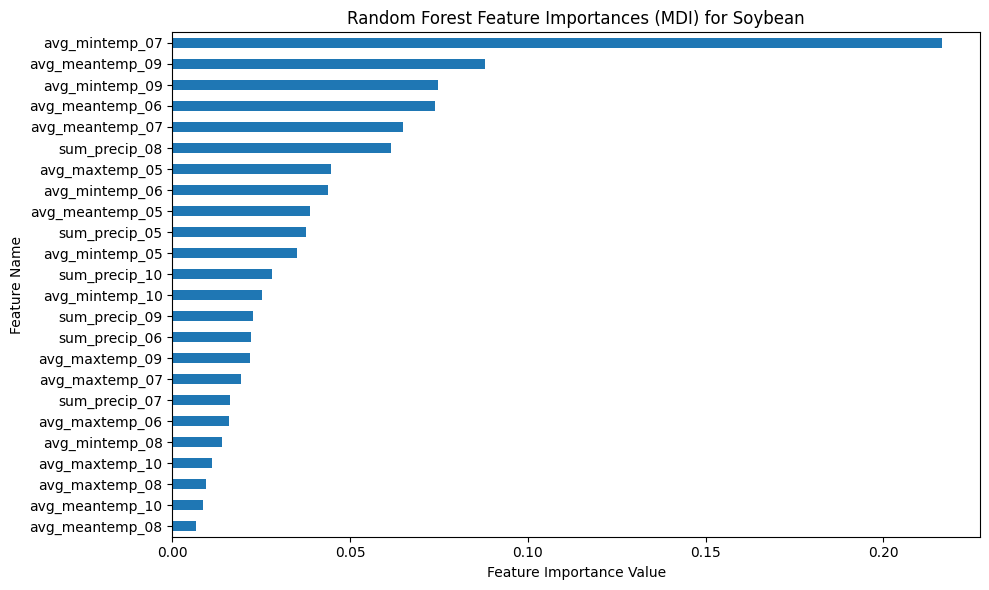

Score: 0.92
Out-of-Bag Score: 0.39839364465988203
Mean Squared Error: 7.5822652619047854
R-squared: 0.9175746517782611
Features sorted by their score:
[(np.float64(0.2164), 'avg_mintemp_07'), (np.float64(0.0881), 'avg_meantemp_09'), (np.float64(0.0748), 'avg_mintemp_09'), (np.float64(0.0739), 'avg_meantemp_06'), (np.float64(0.0648), 'avg_meantemp_07'), (np.float64(0.0615), 'sum_precip_08'), (np.float64(0.0445), 'avg_maxtemp_05'), (np.float64(0.0437), 'avg_mintemp_06'), (np.float64(0.0386), 'avg_meantemp_05'), (np.float64(0.0377), 'sum_precip_05'), (np.float64(0.0351), 'avg_mintemp_05'), (np.float64(0.0279), 'sum_precip_10'), (np.float64(0.0251), 'avg_mintemp_10'), (np.float64(0.0226), 'sum_precip_09'), (np.float64(0.0222), 'sum_precip_06'), (np.float64(0.0218), 'avg_maxtemp_09'), (np.float64(0.0194), 'avg_maxtemp_07'), (np.float64(0.0161), 'sum_precip_07'), (np.float64(0.0159), 'avg_maxtemp_06'), (np.float64(0.0138), 'avg_mintemp_08'), (np.float64(0.0112), 'avg_maxtemp_10'), (np.float6

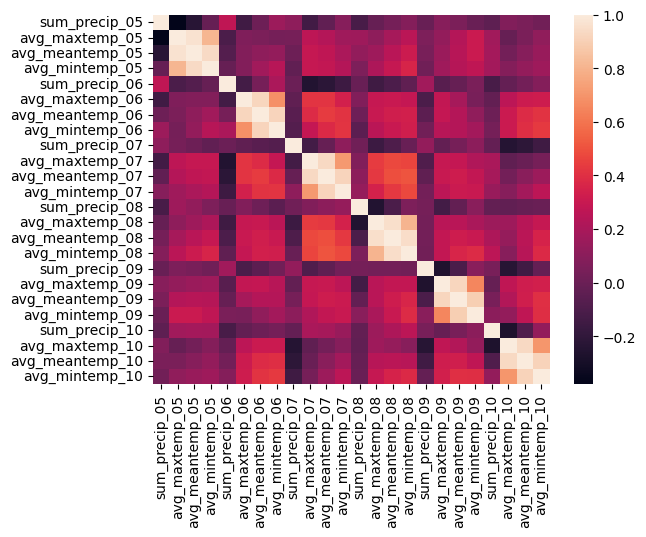

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import make_regression


# 0. initial variables
stationID = '6149625'
startYear = 1942
endYear = 2025
crop_yield_filename = 'Ontario_corn_soybeans_and_winter_wheat_yields_1942_to_2025.csv'

# 1. load data
#   read crop yields data from csv file
cols = ['year', 'Grain Corn', 'Soybean', 'Winter Wheat']
crop_yield_df = pd.read_csv(crop_yield_filename, usecols=['year', 'Grain Corn', 'Soybean', 'Winter Wheat'], dtype={'year': str})

#   read weather data from 1942 to 2025 and weather data cleaning
cols = ['Date/Time', 'Year', 'Month', 'Day', 'Max Temp (°C)', 'Min Temp (°C)', 'Mean Temp (°C)', 'Total Rain (mm)', 'Total Precip (mm)']
df = pd.DataFrame()
for year in range(startYear, endYear+1):
    daily_df = pd.read_csv(f'Station_{stationID}_{year}.csv', usecols=cols, dtype = {'Date/Time': str, 'Year': str, 'Month': str, 'Day': str})
    df = pd.concat([df, daily_df], ignore_index=True)

#   Filter weather rows where 'month' is in period from November 1st to April 30th
months = ['05', '06', '07', '08', '09', '10']
summer_weather_df = df[df['Month'].isin(months)]


# 2. Group weather data by ['Year','Month'] and generate statistics data  * * * * * * * * * *
summer_weather_group = summer_weather_df.groupby(['Year','Month'])
summer_weather_stats = summer_weather_group.agg(
                    avg_maxtemp=('Max Temp (°C)', 'mean'),
                    avg_mintemp=('Min Temp (°C)', 'mean'),
                    avg_meantemp=('Mean Temp (°C)', 'mean'),
                    min_mintemp=('Min Temp (°C)', 'min'),
                    sum_rain=('Total Rain (mm)', 'sum'),
                    sum_precip=('Total Precip (mm)', 'sum')).reset_index()


# combine 30 weather variables
months = ['05', '06', '07', '08', '09', '10']
combine_weather_df = pd.DataFrame()
for month in months:
    month_df = summer_weather_stats.loc[summer_weather_stats['Month'] == month].copy().reset_index()
    combine_weather_df['sum_precip_'+month] = month_df['sum_precip']
    combine_weather_df['avg_maxtemp_'+month] = month_df['avg_maxtemp']
    combine_weather_df['avg_meantemp_'+month] = month_df['avg_meantemp']
    combine_weather_df['avg_mintemp_'+month] = month_df['avg_mintemp']

print(combine_weather_df.head())

# 3. Extract Feature Importances for Soybean yield
#   split data
X = combine_weather_df
y = crop_yield_df['Soybean']

#   RandomForestRegressor model
reg = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
reg.fit(X, y)

#   Feature Importances
importances = reg.feature_importances_
feature_names = X.columns

#   Create a pandas Series for easier manipulation and plotting
feature_series = pd.Series(importances, index=feature_names).sort_values(ascending=True)

#   Plot the Feature Importances
plt.figure(figsize=(10, 6))
feature_series.plot(kind='barh')
plt.title("Random Forest Feature Importances (MDI) for Soybean")
plt.xlabel("Feature Importance Value")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

#   Evaluate Random Forest performance using R-Squared
print('Score: %.2f' % reg.score(X, y, sample_weight=None))
print("Out-of-Bag Score:", reg.oob_score_)

y_pred = reg.predict(X)
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y, y_pred)
print("R-squared:", r2)



# 4. Head map
print("Features sorted by their score:")
print(sorted(zip(map(lambda x: round(x, 4), reg.feature_importances_), X.columns), reverse=True))

# correlations
combine_weather_df.corr()
import seaborn as sn
import matplotlib.pyplot as plt
corrMatrix = combine_weather_df.corr()
sn.heatmap(corrMatrix, annot=False)
plt.show()






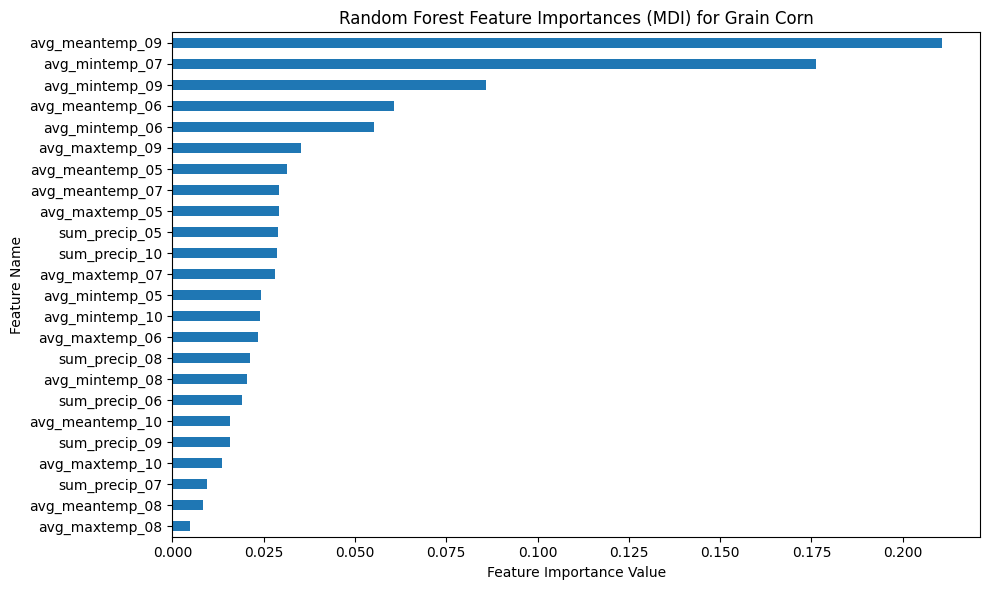

Score: 0.92
Out-of-Bag Score: 0.43206176489709724
Mean Squared Error: 130.76308079761932
R-squared: 0.920748767636408


In [ ]:
# 5. Extract Feature Importances for Grain Corn
#   split data
X = combine_weather_df
y = crop_yield_df['Grain Corn']

#   RandomForestRegressor model
reg = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
reg.fit(X, y)

#   Feature Importances
importances = reg.feature_importances_
feature_names = X.columns

#   Create a pandas Series for easier manipulation and plotting
feature_series = pd.Series(importances, index=feature_names).sort_values(ascending=True)

#   Plot the Feature Importances
plt.figure(figsize=(10, 6))
feature_series.plot(kind='barh')
plt.title("Random Forest Feature Importances (MDI) for Grain Corn")
plt.xlabel("Feature Importance Value")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()
#   Evaluate Random Forest performance using R-Squared
print('Score: %.2f' % reg.score(X, y, sample_weight=None))
print("Out-of-Bag Score:", reg.oob_score_)

y_pred = reg.predict(X)
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)
r2 = r2_score(y, y_pred)
print("R-squared:", r2)






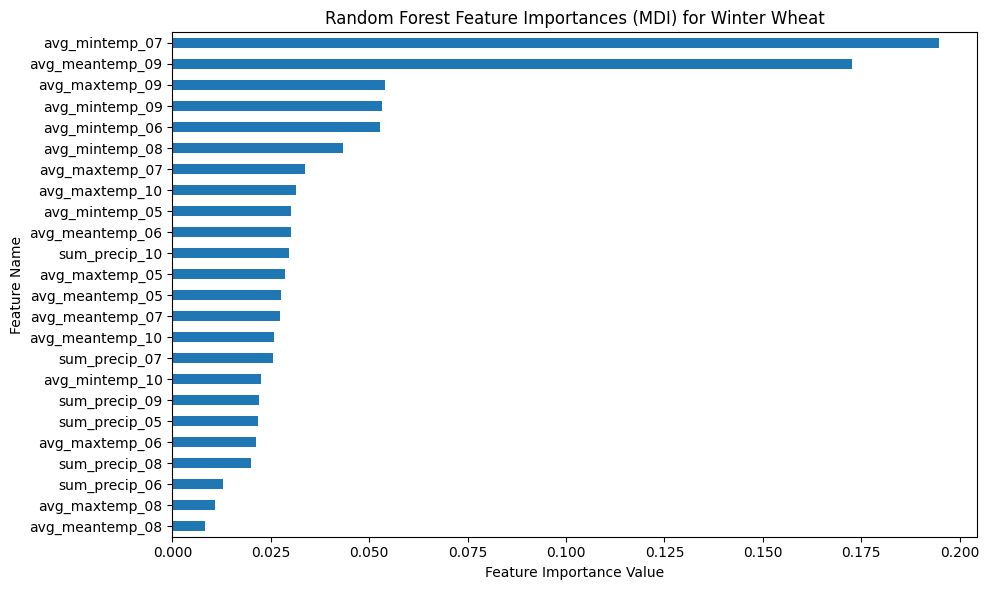

Score: 0.90
Out-of-Bag Score: 0.2990605382140695
Mean Squared Error: 42.011638250000146
R-squared: 0.901657738762746


In [ ]:
# 5. Extract Feature Importances for Winter Wheat
#   split data
X = combine_weather_df
y = crop_yield_df['Winter Wheat']

#   RandomForestRegressor model
reg = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
reg.fit(X, y)

#   Feature Importances
importances = reg.feature_importances_
feature_names = X.columns

#   Create a pandas Series for easier manipulation and plotting
feature_series = pd.Series(importances, index=feature_names).sort_values(ascending=True)

#   Plot the Feature Importances
plt.figure(figsize=(10, 6))
feature_series.plot(kind='barh')
plt.title("Random Forest Feature Importances (MDI) for Winter Wheat")
plt.xlabel("Feature Importance Value")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()
#   Evaluate Random Forest performance using R-Squared
print('Score: %.2f' % reg.score(X, y, sample_weight=None))
print("Out-of-Bag Score:", reg.oob_score_)

y_pred = reg.predict(X)
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)
r2 = r2_score(y, y_pred)
print("R-squared:", r2)